# Infraslow fluctuation of sigma power (ISFS) — filtered course, standardized, phase bins

Minimal notebook: loads one subject's already-preprocessed artifacts from
`preprocessing.py` (envelope, ISFS low-pass, N2 bouts, spindle summary --
see `DATA_DIR` below), finds spindle-containing N2 bouts, and plots that
data -- no raw EDF loading, spindle detection, or envelope/filter
computation happens here; `preprocessing.py` already did all of that once,
this notebook just reads the results.

Then plots that one bout's filtered sigma-power course, standardized (z-scored), with
peaks, troughs and zero-crossings marked, and one valid ISFS cycle (period 25-100 s,
containing both a peak and a trough) split into eight phase bins (1-4 negative half
wave, 5-8 positive half wave).


In [1]:
%reset -f

In [2]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.signal import find_peaks

from infraslow.pipeline import io as pio
from infraslow.processing.infraslow import (
    isfs_phase_bins,
    isfs_event_phase_distribution,
    DEFAULT_ISFS_MIN_EVENTS,
)

plt.rcParams['figure.dpi'] = 110
PURPLE, LPURPLE, BLUE = '#5b2a86', '#c9b3e6', 'tab:blue'


## Load one subject's preprocessed artifacts

In [3]:
DATA_DIR = Path('/scratch/users/chaisaen/usleep_dryrun_v2/data')
SUBJECT = '318562'
CHANNEL = 'C3'
SIGMA_BAND = (11.0, 16.0)      # sigma power = |power| averaged over 11-16 Hz -- informational
                                # only here, envelope/sigma.npz below was already computed with it
MIN_BOUT_SEC = 200             # informational only -- preprocessing.py already enforced this
                                # (consecutive N2 bouts >= 200s) when it wrote spindle_bouts.npz
HYPNO_EPOCH_SEC = 3.0          # must match whatever --hypno-epoch-sec preprocessing.py was run
                                # with -- selects which <stage>/<N>s/ directory to read
ISFS_PERIOD = (25.0, 100.0)    # infraslow time scale (s)

subject_dir = DATA_DIR / SUBJECT

# preprocessing.py's N2/<HYPNO_EPOCH_SEC>s/spindle_bouts.npz: "all" = every consecutive-N2
# bout >= MIN_BOUT_SEC (found from this channel's own U-Sleep hypnogram, not a raw scored
# CSV), "spindle" = the subset of those bouts containing >= 1 detected spindle.
bout_arrays = pio.load_stage_bouts(subject_dir, CHANNEL, 'N2', hypno_epoch_sec=HYPNO_EPOCH_SEC)
bouts_all = [tuple(row) for row in bout_arrays['all']]
bouts = [tuple(row) for row in bout_arrays['spindle']]

spindle_summary = pio.load_spindle_summary(subject_dir, CHANNEL, 'N2', hypno_epoch_sec=HYPNO_EPOCH_SEC)
peaks = spindle_summary['Peak'].to_numpy()

total_min = sum(b - a for a, b in bouts) / 60
print(f'{SUBJECT} {CHANNEL}: {len(bouts_all)} NREM2 bout(s) >= {MIN_BOUT_SEC:g}s')
print(f'{len(peaks)} spindles detected (whole night, N2 epochs)')
print(f'{len(bouts)}/{len(bouts_all)} bout(s) contain >= 1 spindle; total {total_min:.1f} min')


318562 C3: 11 NREM2 bout(s) >= 200s
239 spindles detected (whole night, N2 epochs)
11/11 bout(s) contain >= 1 spindle; total 71.5 min


*(Bout-finding and spindle detection are no longer done here -- both already
happened once inside `preprocessing.py`; the cell above just reads the results.)*

In [4]:
bouts_all

[(np.float64(9267.0), np.float64(9720.0)),
 (np.float64(15090.0), np.float64(15504.0)),
 (np.float64(15705.0), np.float64(15954.0)),
 (np.float64(20343.0), np.float64(20724.0)),
 (np.float64(20730.0), np.float64(21489.0)),
 (np.float64(21696.0), np.float64(22179.0)),
 (np.float64(22389.0), np.float64(22659.0)),
 (np.float64(23076.0), np.float64(23388.0)),
 (np.float64(24357.0), np.float64(24594.0)),
 (np.float64(24606.0), np.float64(25092.0)),
 (np.float64(25176.0), np.float64(25425.0))]

# Select which N2 bout to visualize (drives Figure 6)


In [5]:
# --- Select which N2 bout to visualize (drives Figure 6) ---
# Change BOUT_IDX to any value in range(len(bouts)) to move which bout Figure 6 tracks.
BOUT_IDX = 3
if bouts:
    BOUT_IDX = max(0, min(BOUT_IDX, len(bouts) - 1))   # clamp to a valid bout
    bout0 = bouts[BOUT_IDX]
    print(f'Selected bout #{BOUT_IDX} of {len(bouts)}: {bout0[0]:.0f}-{bout0[1]:.0f}s '
          f'({bout0[1] - bout0[0]:.0f}s)')
else:
    bout0 = None
    print(f'{SUBJECT} {CHANNEL}: no spindle-containing N2 bouts -- Figure 6 below will be '
          'skipped (pick a different SUBJECT, e.g. one from a hypnodensity_isfs_phase run\'s '
          'usable_subjects_N2.csv, to see it)')


Selected bout #3 of 11: 20343-20724s (381s)


## Sigma-power envelope

Morlet wavelet analytic power (11-16 Hz), averaged into 1 s bins, in dB --
loaded from `preprocessing.py`'s `envelope/sigma.npz` (computed once, whole
night), not recomputed here.


In [6]:
t_env, sigma_db = pio.load_envelope(subject_dir, CHANNEL, 'sigma')

def env_at(times, t=t_env, y=sigma_db):
    """Envelope (power or amplitude, matching sigma_db) value interpolated at spindle
    peak times (for the blue dots) -- matches the plotted curve's own y-axis, not
    YASA's own per-spindle Amplitude summary column."""
    return np.interp(times, t, y)


In [7]:
t_env

array([5.00000e-01, 1.50000e+00, 2.50000e+00, ..., 2.76435e+04,
       2.76445e+04, 2.76455e+04], shape=(27646,))

## Continuous ISFS low-pass (Figure 6 input)

`isfs_lowpass` (Tukey-tapered 5th-order Butterworth, -3 dB @ 0.04 Hz, `filtfilt`,
matching the reference `get_iso`) applied **once** to the whole-night `sigma_db`
course -- loaded here from `preprocessing.py`'s `temporal_ISFS/sigma.npz`
(computed once, whole night), not recomputed. Figure 6 below slices this
pre-filtered course to one bout instead of re-filtering that short segment on
its own, so the Tukey taper and `filtfilt` edge padding only touch the
start/end of the whole recording -- not the bout's own edges.


In [8]:
_t_env_check, sigma_lp_full = pio.load_temporal_isfs(subject_dir, CHANNEL, 'sigma')
assert np.array_equal(t_env, _t_env_check), 'envelope/ and temporal_ISFS/ t_env grids must match'


## Figure 6 — filtered sigma power, standardization & phase bins

Top: the sigma-power course (grey) with spindles (blue dots) and the infraslow
filtered course (black) -- `sigma_lp_full` (the continuous, whole-night `isfs_lowpass`
output computed once above) sliced to this bout. Bottom: that course standardized
(z-scored), with peaks, troughs and zero-crossings marked, over the **whole bout**.
`isfs_phase_bins` finds every valid ISFS cycle in the bout (period 25-100 s,
containing both a peak and a trough) and splits each into eight phase bins: 1-4
quarter the negative half wave around its own trough (1/2 split at the mean sample
index between the half-wave's start and the trough, 2/3 at the trough itself, 3/4 at
the mean sample index between the trough and the midpoint); bins 5-8 mirror this
around the positive half wave's peak -- not equal-width slices, each bin's width
follows where the trough/peak actually falls. Every valid cycle found is shaded and
numbered 1-8; everything else in the bout -- signal that isn't on the 25-100 s
infraslow time scale, and/or sits at the start/end of the bout without a complete
peak+trough -- is shaded grey and labeled **Not ISFS**, per the reference `get_iso`.

In [9]:
# --- Figure 6 tracks the bout selected above (BOUT_IDX) ---
if bout0 is not None:
    PHASE_BOUT = BOUT_IDX          # index into `bouts`

    # --- Slice the chosen bout's course out of the continuous, whole-night
    # sigma_lp_full (loaded once, above) -- no per-bout filter edge effects ---
    a, b = bouts[PHASE_BOUT]
    m0 = (t_env >= a) & (t_env < b)
    tt = t_env[m0] - a                       # bout-relative time (s), 1 Hz sampling
    raw = sigma_db[m0]
    filt = sigma_lp_full[m0]
    std = (filt - filt.mean()) / filt.std()  # standardized (z-scored) filtered course

    # --- Every valid ISFS cycle in this bout, each split into 8 phase bins
    # (isfs_phase_bins, matching the reference get_iso) -- bins 1-4 quarter the
    # negative half-wave around its own trough, 5-8 the positive half-wave around its
    # own peak; every sample outside a valid 25-100 s cycle is "Not ISFS" (bin 0). ---
    phase_bins, isfs_cycles = isfs_phase_bins(tt, std, isfs_period=ISFS_PERIOD)
    print(f'{len(isfs_cycles)} valid ISFS cycle(s) found in bout #{PHASE_BOUT} '
          f'({(phase_bins > 0).sum()}/{phase_bins.size} samples in an ISFS cycle)')


8 valid ISFS cycle(s) found in bout #3 (339/381 samples in an ISFS cycle)


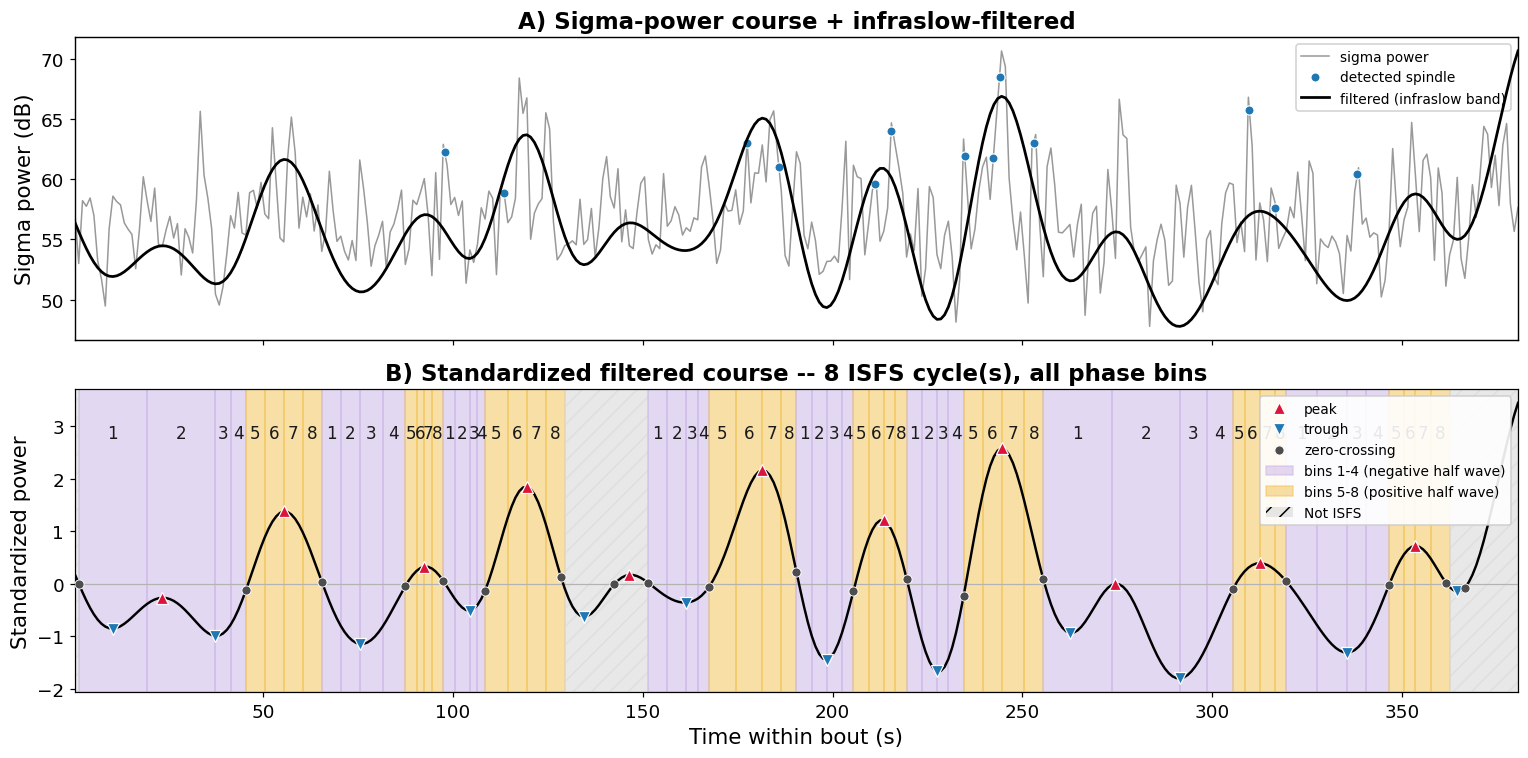

In [10]:
if bout0 is None:
    print('Skipping Figure 6 -- no spindle-containing N2 bout for this subject.')
else:
    fig, (axT, axB) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

    # --- Top: sigma-power course (grey), spindles (blue dots), filtered course (black) ---
    axT.plot(tt, sigma_db[m0], color='0.6', lw=1.0, label='sigma power')
    pk_t = peaks[(peaks >= a) & (peaks < b)]
    axT.plot(pk_t - a, env_at(pk_t), 'o', color=BLUE, ms=6, mec='white', mew=0.8,
             zorder=5, label='detected spindle')
    axT2 = axT.twinx()
    axT2.plot(tt, filt, color='k', lw=1.8, label='filtered (infraslow band)')
    axT2.set_yticks([])
    axT.set_ylabel('Sigma power (dB)', fontsize=14)
    axT.set_title('A) Sigma-power course + infraslow-filtered', fontsize=15, fontweight='bold')
    axT.tick_params(labelsize=12)
    l1, la1 = axT.get_legend_handles_labels()
    l2, la2 = axT2.get_legend_handles_labels()
    axT.legend(l1 + l2, la1 + la2, loc='upper right', frameon=True, framealpha=0.9, fontsize=9)

    # --- Bottom: standardized course, all peaks/troughs/zero-crossings, every
    # detected cycle's 8 phase bins, and explicit "Not ISFS" spans ---
    pk_i, _ = find_peaks(std)
    tr_i, _ = find_peaks(-std)
    zc_i = np.where(np.diff(np.signbit(std)))[0]

    axB.axhline(0, color='0.7', lw=0.8)
    axB.plot(tt, std, color='k', lw=1.6)
    axB.plot(tt[pk_i], std[pk_i], '^', color='crimson', ms=8, mec='white', mew=0.8,
             zorder=5, label='peak')
    axB.plot(tt[tr_i], std[tr_i], 'v', color='tab:blue', ms=8, mec='white', mew=0.8,
             zorder=5, label='trough')
    axB.plot(tt[zc_i], std[zc_i], 'o', color='0.3', ms=6, mec='white', mew=0.6,
             zorder=5, label='zero-crossing')
    axB.tick_params(labelsize=12)

    # Shade every contiguous run of phase_bins: 0 = Not ISFS (grey, hatched), 1-8 =
    # the phase bin (numbered, colored by half-wave) -- covers the whole bout, not
    # just the first cycle.
    run_edges = np.flatnonzero(np.diff(phase_bins) != 0)
    run_starts = np.concatenate([[0], run_edges + 1])
    run_ends = np.concatenate([run_edges + 1, [phase_bins.size]])
    y_top = axB.get_ylim()[1] if axB.get_ylim()[1] > 0 else 1.0
    for s_i, e_i in zip(run_starts, run_ends):
        label = int(phase_bins[s_i])
        x0, x1 = tt[s_i], tt[min(e_i, phase_bins.size - 1)]
        if label == 0:
            axB.axvspan(x0, x1, color='0.85', alpha=0.6, hatch='//', zorder=0)
            continue
        col = LPURPLE if label <= 4 else '#f2c14e'
        axB.axvspan(x0, x1, color=col, alpha=0.5, zorder=0)
        axB.text((x0 + x1) / 2, y_top * 0.82, str(label),
                 ha='center', va='top', fontsize=11, color='0.1',
                 zorder=6)

    legB = axB.legend(handles=axB.get_legend_handles_labels()[0] + [
        Patch(color=LPURPLE, alpha=0.5, label='bins 1-4 (negative half wave)'),
        Patch(color='#f2c14e', alpha=0.5, label='bins 5-8 (positive half wave)'),
        Patch(facecolor='0.85', alpha=0.6, hatch='//', label='Not ISFS')],
        loc='upper right', frameon=True, framealpha=0.9, fontsize=9)
    legB.set_zorder(10)

    axB.set(xlim=(float(tt[0]), float(tt[-1])))
    axB.set_xlabel('Time within bout (s)', fontsize=14)
    axB.set_ylabel('Standardized power', fontsize=14)
    axB.set_title(f'B) Standardized filtered course -- {len(isfs_cycles)} ISFS cycle(s), '
                  'all phase bins', fontsize=15, fontweight='bold')
    fig.tight_layout()


## Figure 7 — spindle distribution across ISFS phase bins

`isfs_event_phase_distribution`, across **every** spindle-containing N2 bout (not
just `BOUT_IDX`): each detected spindle peak is assigned to the ISFS phase bin of
its nearest sample (or "Not ISFS" if outside a valid 25-100 s cycle), and each
bin's count is expressed as a percentage of the **total** number of spindles
detected for this subject/channel -- the reference `get_iso`'s own denominator, so
the 8 percentages need not sum to 100. That remainder is shown explicitly as a 9th
bar right after bin 8 (grey, hatched) -- the same total minus the 8 bins' counts, as
a percentage. Per the reference, this subject/channel is excluded if fewer than
`DEFAULT_ISFS_MIN_EVENTS` (5) spindles were detected in total.

Underneath (same %-axis as the bars, shared 0-line) is a smooth **schematic**
sine curve -- not real amplitude data -- marking where bins 1-4/5-8 sit on a
phase cycle, shifted below 0 so it reads as a phase strip under the bars rather
than competing with them for vertical space.


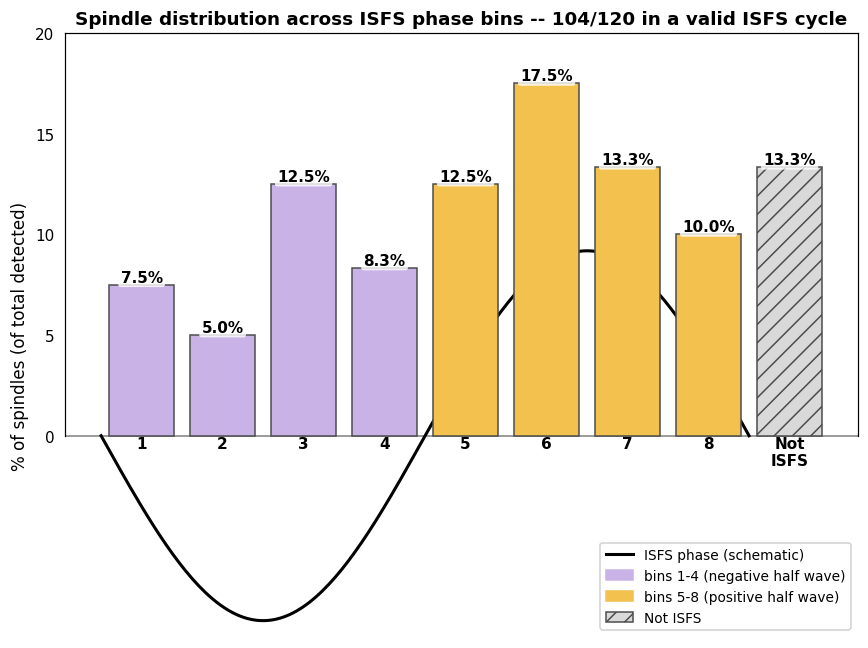

In [11]:
# --- Every bout's (t, phase_bins, spindle_times), all on that bout's own
# bout-relative time base -- sigma_lp_full is already filtered once, above ---
bouts_data = []
for a, b in bouts:
    m0 = (t_env >= a) & (t_env < b)
    tt_b = t_env[m0] - a
    filt_b = sigma_lp_full[m0]
    std_b = (filt_b - filt_b.mean()) / filt_b.std()
    phase_bins_b, _ = isfs_phase_bins(tt_b, std_b, isfs_period=ISFS_PERIOD)
    pk_t_b = peaks[(peaks >= a) & (peaks < b)] - a
    bouts_data.append((tt_b, phase_bins_b, pk_t_b))

dist = isfs_event_phase_distribution(bouts_data, min_events=DEFAULT_ISFS_MIN_EVENTS)

fig, ax = plt.subplots(figsize=(8, 6))
if dist is None:
    ax.axis('off')
    ax.text(0.5, 0.5, f'Excluded: fewer than {DEFAULT_ISFS_MIN_EVENTS} spindles detected',
            ha='center', va='center', fontsize=13, transform=ax.transAxes)
else:
    label_bbox = dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='none', alpha=0.8)
    bins8 = np.arange(1, 9)
    colors = [LPURPLE if b <= 4 else '#f2c14e' for b in bins8]
    ax.bar(bins8, dist['pct'], color=colors, edgecolor='0.3', zorder=2)
    for b, pct in zip(bins8, dist['pct']):
        ax.text(b, pct, f'{pct:.1f}%', ha='center', va='bottom', fontsize=10,
                fontweight='bold', bbox=label_bbox, zorder=6)

    not_isfs_pct = 100.0 * (dist['n_total'] - dist['n_in_isfs']) / dist['n_total']
    ax.bar(9, not_isfs_pct, color='0.85', edgecolor='0.3', hatch='//', zorder=2)
    ax.text(9, not_isfs_pct, f'{not_isfs_pct:.1f}%', ha='center', va='bottom', fontsize=10,
            fontweight='bold', bbox=label_bbox, zorder=6)

    # No tick labels here for bins 1-8 or "Not ISFS" (x=9) -- all placed
    # manually at y=0 below, instead of at the default tick position (which
    # would sit far below the bars once the y-axis is extended downward to fit
    # the phase curve).
    ax.set(xticks=list(bins8) + [9], xticklabels=[''] * (len(bins8) + 1))
    # ax.set_xlabel('ISFS phase bin', fontsize=11)
    ax.set_ylabel('% of spindles (of total detected)', fontsize=11)
    ax.set_title(f"Spindle distribution across ISFS phase bins -- "
                 f"{dist['n_in_isfs']}/{dist['n_total']} in a valid ISFS cycle",
                 fontsize=12, fontweight='bold')
    ax.tick_params(labelsize=10)

    # Schematic phase reference, same %-axis as the bars: one smooth sine period
    # across the 8 bins (bin edges 0.5-8.5) -- *not* offset by a baseline, so its
    # first point (x=0.5, the start of bin 1) sits exactly on the shared 0% line.
    y0, y1 = ax.get_ylim()
    span = y1 - y0
    amp = 0.50 * span
    x_smooth = np.linspace(0.5, 8.5, 200)
    y_smooth = -amp * np.sin(2 * np.pi * (x_smooth - 0.5) / 8)
    ax.plot(x_smooth, y_smooth, color='k', lw=2.0, ls='-', zorder=1,
            label='ISFS phase (schematic)')
    ax.axhline(0, color='0.5', lw=1.0, zorder=0)
    ax.set_ylim(min(y0, -amp - 0.03 * span), max(y1, amp + 0.03 * span))

    # Bin-number (1-8) and "Not ISFS" (9) tick labels, placed at the shared y=0
    # line instead of the default tick position (now far below the bars, since
    # the axis extends down to fit the phase curve above).
    for b in bins8:
        ax.text(b, 0, str(b), ha='center', va='top', fontsize=10, fontweight='bold')
    ax.text(9, 0, 'Not\nISFS', ha='center', va='top', fontsize=10, fontweight='bold')

    # Negative y-tick labels are meaningless (the phase curve is schematic, not
    # real %) -- blank them, keeping 0 and the positive (real, % of events) ticks.
    yticks = ax.get_yticks()
    ax.set_yticks(yticks)
    ax.set_yticklabels([f'{t:g}' if t >= 0 else '' for t in yticks])
    plt.tick_params(axis='both', bottom=False, left=False) 

    # Drop the x-axis frame (bottom spine) -- the axhline(0) above already marks
    # the real zero line -- and clip the left/right spines to start at 0 instead
    # of running down through the (schematic-curve-only) negative region below it.
    _, y1f = ax.get_ylim()
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_bounds(0, y1f)
    ax.spines['right'].set_bounds(0, y1f)

    ax.legend(handles=ax.get_legend_handles_labels()[0] + [
        Patch(color=LPURPLE, label='bins 1-4 (negative half wave)'),
        Patch(color='#f2c14e', label='bins 5-8 (positive half wave)'),
        Patch(facecolor='0.85', edgecolor='0.3', hatch='//', label='Not ISFS')],
        loc='lower right', frameon=True, framealpha=0.9, fontsize=9)
fig.tight_layout()